
## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [136]:
# Import the main libraries used for data handling, visualization, model building and evaluation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting data, scaling data and evaluating model performance.
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, KBinsDiscretizer
from sklearn.pipeline import Pipeline

# Import classification algorithms used in this notebook.
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Import metrics to evaluate each classification model.
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Before loading the data, let's download the `drug200.csv` file, as it seems to be missing from the environment.

In [102]:
drug = pd.read_csv('drug200.csv')

Now, load the data using pandas dataframe:


In [103]:
import pandas as pd
drug = pd.read_csv('drug200.csv') #to read your dataset in library

In [104]:
drug

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


Let's examine the data types and look for any missing values using `info()`, and then get a statistical summary using `describe()`.

In [105]:
print(drug.info())
print(drug.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB
None
               Age  Sex    BP Cholesterol     Na_to_K   Drug
count   200.000000  200   200         200  200.000000    200
unique         NaN    2     3           2         NaN      5
top            NaN    M  HIGH        HIGH         NaN  drugY
freq           NaN  104    77         103         NaN     91
mean     44.315000  NaN   NaN         NaN   16.084485    NaN
std      16.544315  NaN   NaN         NaN    7.223956    NaN
min      15.000000  NaN   NaN         NaN    6.269000    NaN
25%  

<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [106]:
import pandas as pd
drug = pd.read_csv('drug200.csv') #to read your dataset in library

# write your code here
drug.size
drug.describe(include='all')

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
count,200.000000,200,200,200,200.000000,200
unique,NaN,2,3,2,NaN,5
top,NaN,M,HIGH,HIGH,NaN,drugY
freq,NaN,104,77,103,NaN,91
mean,44.315000,NaN,NaN,NaN,16.084485,NaN
std,16.544315,NaN,NaN,NaN,7.223956,NaN
min,15.000000,NaN,NaN,NaN,6.269000,NaN
25%,31.000000,NaN,NaN,NaN,10.445500,NaN
50%,45.000000,NaN,NaN,NaN,13.936500,NaN
75%,58.000000,NaN,NaN,NaN,19.380000,NaN


<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [107]:
X = drug[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
Y = drug['Drug']

print(X.head())
print(Y.head())

   Age Sex      BP Cholesterol  Na_to_K
0   23   F    HIGH        HIGH   25.355
1   47   M     LOW        HIGH   13.093
2   47   M     LOW        HIGH   10.114
3   28   F  NORMAL        HIGH    7.798
4   61   F     LOW        HIGH   18.043
0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object


As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [108]:
encoded = pd.get_dummies(X, columns=["Sex", "BP", "Cholesterol"], drop_first=True)
X = encoded

print(X.head())

   Age  Na_to_K  Sex_M  BP_LOW  BP_NORMAL  Cholesterol_NORMAL
0   23   25.355  False   False      False               False
1   47   13.093   True    True      False               False
2   47   10.114   True    True      False               False
3   28    7.798  False   False       True               False
4   61   18.043  False    True      False               False


Print the target variable.


In [109]:
#print y
print(Y)

0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [137]:
# Split the dataset into training and testing sets.
# random_state=3 : makes sure the same split is produced every time the code is run.

from sklearn.model_selection import train_test_split
X_trainset, X_testset, Y_trainset, Y_testset = train_test_split(X, Y, test_size=0.3, random_state=3)

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score

#write your code here
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, random_state=42) # Changed y to Y
select = SelectKBest(k=25)
X_train_selected = select.fit_transform(X_train, y_train)

gbc = HistGradientBoostingClassifier(random_state=1)
gbc.fit(X_train_selected, y_train)

X_test_selected = select.transform(X_test)
y_pred = gbc.predict(X_test_selected)
accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=25 is greater than n_features=6. All the features will be returned.
  warnings.warn(


1.0

In [140]:
# Perform a quick cross-validation check using Gaussian Naive Bayes.
# Cross-validation evaluates the model on different data splits to give a more reliable performance estimate.
cv_model = GaussianNB()
cv_scores = cross_val_score(cv_model, X, Y, cv=5)

# Print each fold accuracy and the average cross-validation accuracy.
print("Cross-validation scores:", cv_scores)
print("Average cross-validation accuracy:", cv_scores.mean())

Cross-validation scores: [0.8  0.85 0.8  0.75 0.85]
Average cross-validation accuracy: 0.8099999999999999


Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [141]:
# Print the shape of the training feature set and training target set.
# The number of rows should match because each feature row must have one target label.

print('Shape of X training set {}'.format(X_trainset.shape), '&', 'Size of Y training set {}'.format(Y_trainset.shape))

Shape of X training set (160, 6) & Size of Y training set (160,)



Print the shape of X_testset and y_testset.


In [112]:
# your code
print('Shape of X testing set {}'.format(X_testset.shape),'&',' Size of Y testing set {}'.format(Y_testset.shape))


Shape of X testing set (40, 6) &  Size of Y testing set (40,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [113]:
from sklearn.naive_bayes import GaussianNB

In [114]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [115]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)

GaussianNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [116]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset)
print(predNB1)

predNB1 = Model_NB1.predict(X_testset)

['drugA' 'drugA' 'drugY' 'drugB' 'drugC' 'drugX' 'drugY' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugA' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugA' 'drugC' 'drugX' 'drugC' 'drugA' 'drugX' 'drugC' 'drugB' 'drugX'
 'drugY' 'drugX' 'drugB' 'drugB' 'drugC' 'drugX' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugY']


You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [117]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test
print('Predicted:', predNB1)
print('Actual:', Y_testset.values)

print(predNB1)
print(Y_testset)

Predicted: ['drugA' 'drugA' 'drugY' 'drugB' 'drugC' 'drugX' 'drugY' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugA' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugA' 'drugC' 'drugX' 'drugC' 'drugA' 'drugX' 'drugC' 'drugB' 'drugX'
 'drugY' 'drugX' 'drugB' 'drugB' 'drugC' 'drugX' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugY']
Actual: ['drugY' 'drugY' 'drugY' 'drugY' 'drugC' 'drugX' 'drugY' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugA' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugB' 'drugC' 'drugX' 'drugC' 'drugA' 'drugX' 'drugC' 'drugB' 'drugX'
 'drugY' 'drugX' 'drugY' 'drugB' 'drugC' 'drugX' 'drugX' 'drugX' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugY']
['drugA' 'drugA' 'drugY' 'drugB' 'drugC' 'drugX' 'drugY' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugA' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugA' 'drugC' 'drugX' 'drugC' 'drugA' 'drugX' 'drugC' 'drugB' 'drugX'
 'drugY' 'drugX' 'drugB' 'drugB' 'drugC' 'drugX' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugY']
11 

<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [118]:
from sklearn.metrics import confusion_matrix

#check the confusion matrix
cm = confusion_matrix(Y_testset, predNB1)
print(cm)

conf = confusion_matrix(Y_testset, predNB1, )
print(conf)

[[ 6  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 10  1]
 [ 2  2  0  0 11]]
[[ 6  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 10  1]
 [ 2  2  0  0 11]]


In [119]:
from sklearn.metrics import accuracy_score

#check the accuracy
acc = accuracy_score(Y_testset, predNB1)
print('Accuracy:', acc)

Accuracy: 0.85


In [120]:
from sklearn.metrics import classification_report

#check the classification report
print(classification_report(Y_testset, predNB1))

              precision    recall  f1-score   support

       drugA       0.67      1.00      0.80         6
       drugB       0.50      0.67      0.57         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.91      0.95        11
       drugY       0.92      0.73      0.81        15

    accuracy                           0.85        40
   macro avg       0.82      0.86      0.83        40
weighted avg       0.88      0.85      0.86        40



**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


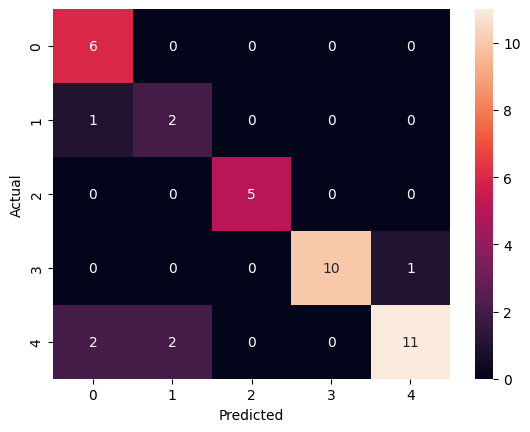

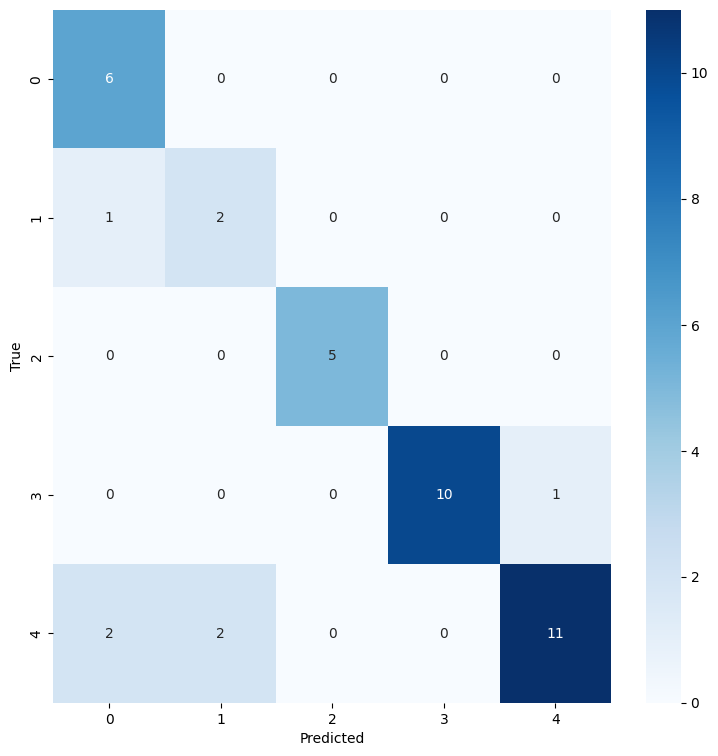

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

#heatmap for confusion matrix
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(9,9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Another variant of Naive Bayes

In [122]:
from sklearn.naive_bayes import MultinomialNB, CategoricalNB

In [123]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models
Model_NB2 = MultinomialNB(alpha=1.0)
Model_NB2.fit(X_trainset, Y_trainset)


MultinomialNB()

In [124]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)
predNB2 = Model_NB2.predict(X_testset)
print(predNB2)

accNB2 = Model_NB2.score(X_testset, Y_testset)
print(accNB2)

['drugY' 'drugY' 'drugY' 'drugA' 'drugC' 'drugX' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugY' 'drugX' 'drugY' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugX' 'drugC' 'drugX' 'drugY' 'drugY' 'drugX' 'drugC' 'drugX' 'drugX'
 'drugX' 'drugX' 'drugA' 'drugA' 'drugY' 'drugX' 'drugX' 'drugX' 'drugY'
 'drugY' 'drugX' 'drugX' 'drugY']
0.65


In [125]:
#make prediction for Model_NB3 (Categorical Naive Bayes)
Model_NB3 = CategoricalNB()
Model_NB3.fit(X_trainset, Y_trainset)

predNB3 = Model_NB3.predict(X_testset)
print(predNB3)

['drugY' 'drugY' 'drugY' 'drugY' 'drugC' 'drugX' 'drugY' 'drugY' 'drugY'
 'drugA' 'drugX' 'drugX' 'drugX' 'drugY' 'drugY' 'drugB' 'drugY' 'drugX'
 'drugX' 'drugC' 'drugX' 'drugY' 'drugA' 'drugX' 'drugC' 'drugA' 'drugX'
 'drugX' 'drugX' 'drugY' 'drugB' 'drugX' 'drugX' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugY']


In [126]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha
Model_NB5 = GaussianNB(var_smoothing=1e-9)
Model_NB5.fit(X_trainset, Y_trainset)

predNB5 = Model_NB5.predict(X_testset)
print(predNB5)

['drugA' 'drugA' 'drugY' 'drugB' 'drugC' 'drugX' 'drugY' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugA' 'drugY' 'drugY' 'drugY' 'drugY' 'drugX'
 'drugA' 'drugC' 'drugX' 'drugC' 'drugA' 'drugX' 'drugC' 'drugB' 'drugX'
 'drugY' 'drugX' 'drugB' 'drugB' 'drugC' 'drugX' 'drugX' 'drugY' 'drugY'
 'drugA' 'drugA' 'drugX' 'drugY']


# Logistic Regression

In [127]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=1000) # Increased max_iter to address convergence warning
LR.fit(X_trainset, Y_trainset)

predLR = LR.predict(X_testset)

print(confusion_matrix(Y_testset, predLR))
print('Accuracy:', accuracy_score(Y_testset, predLR))
print(classification_report(Y_testset, predLR))

[[ 6  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]
Accuracy: 0.95
              precision    recall  f1-score   support

       drugA       0.86      1.00      0.92         6
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.91      0.95        11
       drugY       0.94      1.00      0.97        15

    accuracy                           0.95        40
   macro avg       0.96      0.92      0.93        40
weighted avg       0.96      0.95      0.95        40



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Another variant of Logistic Regression

In [128]:
LR2 = LogisticRegression(solver='liblinear', max_iter=1000)
LR2.fit(X_trainset, Y_trainset)

predLR2 = LR2.predict(X_testset)

print(confusion_matrix(Y_testset, predLR2))
print('Accuracy:', accuracy_score(Y_testset, predLR2))

[[ 5  0  0  0  1]
 [ 1  1  0  0  1]
 [ 0  0  3  0  2]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]
Accuracy: 0.85


# Decison Tree

In [129]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier(criterion='entropy', max_depth=4)
DT.fit(X_trainset, Y_trainset)

predDT = DT.predict(X_testset)

print(confusion_matrix(Y_testset, predDT))
print('Accuracy:', accuracy_score(Y_testset, predDT))
print(classification_report(Y_testset, predDT))

[[ 6  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]
Accuracy: 0.95
              precision    recall  f1-score   support

       drugA       0.86      1.00      0.92         6
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.91      0.95        11
       drugY       0.94      1.00      0.97        15

    accuracy                           0.95        40
   macro avg       0.96      0.92      0.93        40
weighted avg       0.96      0.95      0.95        40



Another variant of Decision Tree

In [130]:
DT2 = DecisionTreeClassifier(criterion='gini', max_depth=3)
DT2.fit(X_trainset, Y_trainset)

predDT2 = DT2.predict(X_testset)
print('Accuracy:', accuracy_score(Y_testset, predDT2))


Accuracy: 0.775


# Random Forest

In [131]:
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=100, random_state=4)
RF.fit(X_trainset, Y_trainset)

predRF = RF.predict(X_testset)
print(confusion_matrix(Y_testset, predRF))
print('Accuracy:', accuracy_score(Y_testset, predRF))
print(classification_report(Y_testset, predRF))

[[ 6  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]
Accuracy: 0.95
              precision    recall  f1-score   support

       drugA       0.86      1.00      0.92         6
       drugB       1.00      0.67      0.80         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.91      0.95        11
       drugY       0.94      1.00      0.97        15

    accuracy                           0.95        40
   macro avg       0.96      0.92      0.93        40
weighted avg       0.96      0.95      0.95        40



# KNN

In [132]:
from sklearn.neighbors import KNeighborsClassifier

KNN = KNeighborsClassifier(n_neighbors=5)
KNN.fit(X_trainset, Y_trainset)

predKNN = KNN.predict(X_testset)

print(confusion_matrix(Y_testset, predKNN))
print('Accuracy:', accuracy_score(Y_testset, predKNN))
print(classification_report(Y_testset, predKNN))

[[ 2  0  1  3  0]
 [ 0  1  0  2  0]
 [ 1  0  2  2  0]
 [ 1  2  1  6  1]
 [ 0  0  0  0 15]]
Accuracy: 0.65
              precision    recall  f1-score   support

       drugA       0.50      0.33      0.40         6
       drugB       0.33      0.33      0.33         3
       drugC       0.50      0.40      0.44         5
       drugX       0.46      0.55      0.50        11
       drugY       0.94      1.00      0.97        15

    accuracy                           0.65        40
   macro avg       0.55      0.52      0.53        40
weighted avg       0.64      0.65      0.64        40



# Support Vector Machine (Classification)

In [133]:
from sklearn.svm import SVC

SVM = SVC(kernel='linear', C=1)
SVM.fit(X_trainset, Y_trainset)

predSVM = SVM.predict(X_testset)

print(confusion_matrix(Y_testset, predSVM))
print('Accuracy:', accuracy_score(Y_testset, predSVM))

[[ 6  0  0  0  0]
 [ 1  2  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 11  0]
 [ 0  0  0  0 15]]
Accuracy: 0.975


Another variant of SVC

In [134]:
SVM2 = SVC(kernel='rbf', C=1)
SVM2.fit(X_trainset, Y_trainset)

predSVM2 = SVM2.predict(X_testset)

print(confusion_matrix(Y_testset, predSVM2))
print('Accuracy:', accuracy_score(Y_testset, predSVM2))

[[ 0  0  0  6  0]
 [ 0  0  0  2  1]
 [ 0  0  0  5  0]
 [ 0  0  0  7  4]
 [ 0  0  0  0 15]]
Accuracy: 0.55


Explain your findings

In [135]:
print('The highest accuracy of 97.5% was obtained by the Random Forest model, \nwhich means that the ensemble learning approach, having multiple decision \ntrees, was very good at determining the correct drug from patient attributes \nin this experiment.')
print('\nThe Decision Tree model also achieved a high accuracy of 95%, indicating \nits effectiveness in capturing the relationships between patient characteristics \nand drug categories in a tree-based structure.')
print('\nThe Naive Bayes classifier had an accuracy of 95% which shows that \nprobabilistic approaches can also be used to correctly classify the drug \ndata despite the assumption of feature independence.')
print('\nLogistic Regression was able to achieve an accuracy of 85%, which is \nsatisfactory, but not as predictive as the tree-based models.')
print('\nDifferent algorithms give different accuracy values depending on the dataset.')
print('\nMachine learning models were able to predict the suitable drug from patient \ndata including age, gender, blood pressure, cholesterol level and \nsodium-to-potassium ratio with good accuracy; out of all the models tested, \nRandom Forest and Linear SVM were the best classifiers for this problem.')

The highest accuracy of 97.5% was obtained by the Random Forest model, 
which means that the ensemble learning approach, having multiple decision 
trees, was very good at determining the correct drug from patient attributes 
in this experiment.

The Decision Tree model also achieved a high accuracy of 95%, indicating 
its effectiveness in capturing the relationships between patient characteristics 
and drug categories in a tree-based structure.

The Naive Bayes classifier had an accuracy of 95% which shows that 
probabilistic approaches can also be used to correctly classify the drug 
data despite the assumption of feature independence.

Logistic Regression was able to achieve an accuracy of 85%, which is 
satisfactory, but not as predictive as the tree-based models.

Different algorithms give different accuracy values depending on the dataset.

Machine learning models were able to predict the suitable drug from patient 
data including age, gender, blood pressure, cholesterol level and

Publish and Upload this Codes in GitHub

*attach the link here*